# Check MWDC pulser data
The input parquet file should be the output of `streamingv1_to_parquet.py`

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

CH2NS = 0.0009765625 # AMANEQ HRTDC time unit to ns

#spark = SparkSession.builder.getOrCreate()
spark = SparkSession.builder.master("local[10]").getOrCreate()
spark.sparkContext.setLogLevel("ERROR")
spark._jvm.decoders.HRTDCDecoder.registerUDF(spark._jsparkSession)

df = spark.read.parquet("/home/h487/notebooks/jan2026/mwdc/parquet/run1031.parquet")

df_dc = df.filter("femType==5 and (femId==616 or femId==617 or femId==618)").select("femId","data").withColumn("decoded",F.expr("decode_hrtdc_segdata(data)"))
df_dc = df_dc.select("femId","decoded.*").select("femId","hbf.*","data").select("femId","hbfNumber","data").filter("array_size(decoded.data)>0")
df_dc = df_dc.withColumn("ex",F.explode("data")).select("femId","hbfNumber","ex.*")
df_dc = df_dc.withColumn("rand",F.rand().cast("float")).withColumn("tcal", (F.col("time").cast("float") + F.col("rand"))*F.lit(CH2NS).cast("float")).drop("time").drop("rand")
df_dc = df_dc.withColumn("rand",F.rand().cast("float")).withColumn("charge", (F.col("tot").cast("float") + F.col("rand"))*F.lit(CH2NS).cast("float")).drop("tot").drop("rand")
df_dc.show(1)

# Map dc31 and dc32
df_map31 = spark.read.csv("../../mwdc/map/dc31_map.csv",inferSchema=True,header=True).withColumn("id",F.col("id").cast("int")).withColumn("femId",F.col("femId").cast("int")).withColumn("ch",F.col("ch").cast("int"))
df_dc31 = df_dc.join(df_map31,on=["ch","femId"]).drop("ch").drop("femId")
df_map32 = spark.read.csv("../../mwdc/map/dc32_map.csv",inferSchema=True,header=True).withColumn("id",F.col("id").cast("int")).withColumn("femId",F.col("femId").cast("int")).withColumn("ch",F.col("ch").cast("int"))
df_dc32 = df_dc.join(df_map32,on=["ch","femId"]).drop("ch").drop("femId")

df_dc31.show(5)
df_dc32.show(5)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/01/22 09:47:14 WARN Utils: Your hostname, gpuana02, resolves to a loopback address: 127.0.1.1; using 133.11.152.134 instead (on interface enp4s0)
26/01/22 09:47:14 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
26/01/22 09:47:14 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


+-----+---------+---+--------+-------+
|femId|hbfNumber| ch|    tcal| charge|
+-----+---------+---+--------+-------+
|  618| 11441034| 24|516236.4|88.4903|
+-----+---------+---+--------+-------+
only showing top 1 row
+---------+---------+---------+---+
|hbfNumber|     tcal|   charge| id|
+---------+---------+---------+---+
| 11441034| 516229.7| 84.41062| 69|
| 11441034|516229.97|79.908195|105|
| 11441034| 516242.2| 76.39799|122|
| 11441034|516247.25|75.828674| 86|
| 11441034| 516227.8| 81.79429| 41|
+---------+---------+---------+---+
only showing top 5 rows
+---------+---------+--------+---+
|hbfNumber|     tcal|  charge| id|
+---------+---------+--------+---+
| 11441034| 516236.4| 88.4903| 42|
| 11441034| 516244.2| 90.4588| 21|
| 11441034|516245.06|87.55729|  4|
| 11441034| 516248.3|87.14196| 58|
| 11441042|440896.56|86.66371| 42|
+---------+---------+--------+---+
only showing top 5 rows


# Plot charge vs id histogram for DC31
*Run this cell when the pulser signal is connected to DC31*
*Run next cell when it's connected to DC32*

Statistics:
[[0.00000e+00 2.00000e+00 0.00000e+00]
 [0.00000e+00 4.80627e+05 1.40540e+04]
 [0.00000e+00 0.00000e+00 0.00000e+00]]


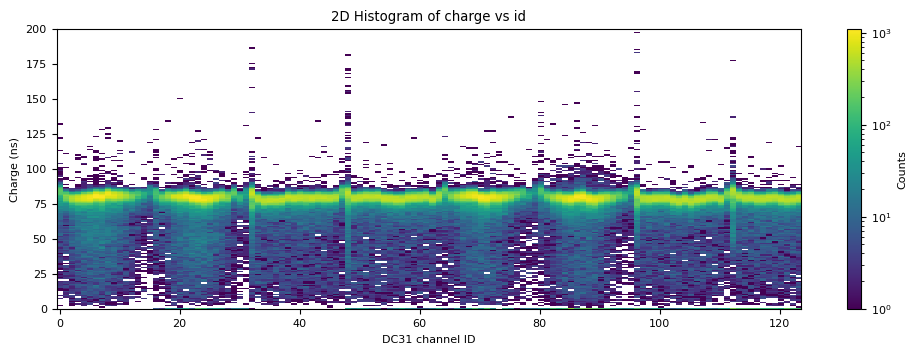

In [6]:
from hist.sparkHist2d import Hist2D
from matplotlib import pyplot as plt
from matplotlib.colors import LogNorm

plt.figure(0, figsize=(12,8))
plt.rcParams["font.size"] = 8
plt.subplot2grid((2,1),(0,0))
h = Hist2D(df_dc31, ["id","charge"], [125,200], [[-0.5, 123.5], [0, 200]], norm=LogNorm(), interpolation='none')
plt.xlabel("DC31 channel ID")
plt.ylabel("Charge (ns)")
#plt.title("DC31 Charge Distribution")
plt.show()

## Plot charge vs id histogram for dc32

Statistics:
[[0.00000e+00 2.00000e+00 0.00000e+00]
 [0.00000e+00 1.34762e+05 0.00000e+00]
 [0.00000e+00 0.00000e+00 0.00000e+00]]


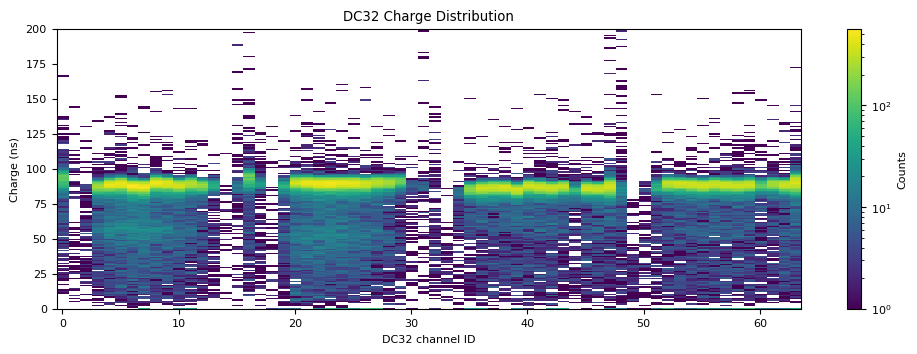

In [ ]:
from hist.sparkHist2d import Hist2D
from matplotlib import pyplot as plt
from matplotlib.colors import LogNorm

plt.figure(0, figsize=(12,8))
plt.rcParams["font.size"] = 8
#plt.subplot2grid((2,1),(0,0))
#h = Hist2D(df_dc31, ["id","charge"], [125,200], [[-0.5, 123.5], [0, 200]], norm=LogNorm(), interpolation='none')
plt.subplot2grid((2,1),(1,0))
h = Hist2D(df_dc32, ["id","charge"], [65,200], [[-0.5, 63.5], [0, 200]], norm=LogNorm(), interpolation='none')
plt.xlabel("DC32 channel ID")
plt.ylabel("Charge (ns)")
#plt.title("DC32 Charge Distribution")
plt.show()